<a href="https://colab.research.google.com/github/rocioivonneperezgonzalez-ship-it/Telecom-X-Parte-2-Predicci-n-de-Cancelaci-n-Churn-/blob/main/Telecom_X_%E2%80%93_Parte_2_Predicci%C3%B3n_de_Cancelaci%C3%B3n_(Churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style = " color:red" Telecom X – Parte 2: Predicción de Cancelación (Churn)</h1>

# <font color='dark'>**Challenge Telecom X- Análisis de evasión de clientes – Parte 2**</h1>
  



📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.


🧠 Objetivos del Desafío


  * Preparar los datos para el modelado (tratamiento, codificación, normalización).

  * Realizar análisis de correlación y selección de variables.

  * Entrenar dos o más modelos de clasificación.

  * Evaluar el rendimiento de los modelos con métricas.

  * Interpretar los resultados, incluyendo la importancia de las variables.

  * Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning

✅ Construcción y evaluación de modelos predictivos

✅ Interpretación de resultados y entrega de insights

✅ Comunicación técnica con enfoque estratégico

# <font color='blue'>***Preparacion de datos***</h1>


## 1. Extracción del Archivo Tratado

Cargar el archivo CSV que contiene los datos tratados anteriormente.
Utilizando el mismo archivo que limpiamos y organizamos en la Parte 1 del desafio, el cuela debe obtener solo las columnsas relevantes, ya con los datos corregidos

In [1]:
import pandas as pd

url = 'https://drive.google.com/uc?id=1kNOO4qdvddUPEOFTu20f4Sa85CjvvyGi'
datos = pd.read_csv(url)

datos.head()


,id,Churn,genero,mayor_de_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,Yes,Cheque enviado por correo,65.6,593.30,19.776667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,No,Cheque enviado por correo,59.9,542.40,18.080000
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensual,Yes,Cheque electrónico,73.9,280.85,9.361667
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensual,Yes,Cheque electrónico,98.0,1237.85,41.261667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensual,Yes,Cheque enviado por correo,83.9,267.40,8.913333


## 2. Eliminación de columnas

Eliminemos columnas que no aportan valor al analisis o a los modelos predictivos, como identificadores unicos ( por ejemplo el ID del cliente). Estas columnas nos ayudan en la predicion de la cancelación y puede incluso perjudicar el desempeño de los modelos

In [2]:
datos.columns

Index(['id', 'Churn', 'genero', 'mayor_de_60', 'posee_pareja',
       'posee_dependientes', 'tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'factura_digital', 'metodo_pago', 'valor_mensal', 'total_cobrado',
       'Cuentas_Diarias'],
      dtype='object')

In [3]:
datos = datos.drop(columns=['id'])

In [4]:
datos.columns

Index(['Churn', 'genero', 'mayor_de_60', 'posee_pareja', 'posee_dependientes',
       'tiempo_contrato', 'servicio_telefono', 'multiples_lineas',
       'tipo_internet', 'seguridad_online', 'backup_online',
       'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv',
       'streaming_peliculas', 'tipo_contrato', 'factura_digital',
       'metodo_pago', 'valor_mensal', 'total_cobrado', 'Cuentas_Diarias'],
      dtype='object')

## 3. Enconding

Transformemos las variables categoricas a formato numerico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un metodo de codificación adecuado, como **[one-hot-enconding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)**


***Sugerencia*** Puedes utilizar los metodos get_dummies o one_hot_enconding

Identifiquemos que columnas son numericas

In [5]:
# Separar variable objetivo
y = datos['Churn']

# Separar variables predictoras
X = datos.drop('Churn', axis=1)


In [6]:
X

,genero,mayor_de_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,Cuentas_Diarias
0,Femenino,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Anual,Yes,Cheque enviado por correo,65.60,593.30,19.776667
1,Masculino,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mensual,No,Cheque enviado por correo,59.90,542.40,18.080000
2,Masculino,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Mensual,Yes,Cheque electrónico,73.90,280.85,9.361667
3,Masculino,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Mensual,Yes,Cheque electrónico,98.00,1237.85,41.261667
4,Femenino,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Mensual,Yes,Cheque enviado por correo,83.90,267.40,8.913333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Femenino,0,0,0,13,1,0,DSL,1,0,0,1,0,0,Anual,No,Cheque enviado por correo,55.15,742.90,24.763333
7039,Masculino,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Mensual,Yes,Cheque electrónico,85.10,1873.70,62.456667
7040,Masculino,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Mensual,Yes,Cheque enviado por correo,50.30,92.75,3.091667
7041,Masculino,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Bienal,No,Cheque enviado por correo,67.85,4627.65,154.255000


In [7]:
type (X)

pandas.core.frame.DataFrame

In [8]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.2 KB


## a) Transformando las varibles explicativas

In [9]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

columnas = X.select_dtypes(include='object').columns

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), columnas),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [10]:
X = one_hot.fit_transform(X)

In [11]:
one_hot.get_feature_names_out()

array(['onehotencoder__genero_Masculino',
       'onehotencoder__multiples_lineas_0',
       'onehotencoder__multiples_lineas_1',
       'onehotencoder__multiples_lineas_Sin servicio de teléfono',
       'onehotencoder__tipo_internet_0',
       'onehotencoder__tipo_internet_DSL',
       'onehotencoder__tipo_internet_Fiber optic',
       'onehotencoder__seguridad_online_0',
       'onehotencoder__seguridad_online_1',
       'onehotencoder__seguridad_online_Sin servicio de internet',
       'onehotencoder__backup_online_0', 'onehotencoder__backup_online_1',
       'onehotencoder__backup_online_Sin servicio de internet',
       'onehotencoder__proteccion_dispositivo_0',
       'onehotencoder__proteccion_dispositivo_1',
       'onehotencoder__proteccion_dispositivo_Sin servicio de internet',
       'onehotencoder__soporte_tecnico_0',
       'onehotencoder__soporte_tecnico_1',
       'onehotencoder__soporte_tecnico_Sin servicio de internet',
       'onehotencoder__streaming_tv_0', 'onehoten

In [12]:
pd.DataFrame(X, columns=one_hot.get_feature_names_out())

,onehotencoder__genero_Masculino,onehotencoder__multiples_lineas_0,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_Sin servicio de teléfono,onehotencoder__tipo_internet_0,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__seguridad_online_0,onehotencoder__seguridad_online_1,onehotencoder__seguridad_online_Sin servicio de internet,...,onehotencoder__metodo_pago_Tarjeta de crédito (automático),onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__mayor_de_60,remainder__posee_pareja,remainder__posee_dependientes,remainder__tiempo_contrato,remainder__servicio_telefono,remainder__valor_mensal,remainder__total_cobrado,remainder__Cuentas_Diarias
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,9.0,1.0,65.60,593.30,19.776667
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9.0,1.0,59.90,542.40,18.080000
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,1.0,73.90,280.85,9.361667
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,13.0,1.0,98.00,1237.85,41.261667
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,3.0,1.0,83.90,267.40,8.913333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,13.0,1.0,55.15,742.90,24.763333
7039,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,22.0,1.0,85.10,1873.70,62.456667
7040,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,50.30,92.75,3.091667
7041,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,67.0,1.0,67.85,4627.65,154.255000


## b) Tranformando la variable respuesta

Como la variable y ya esca codificada como 0 y 1, no es necesartio hacer una ntranformación adicional, por lo tanto nos queda:

In [13]:
y = datos['Churn']

In [14]:
# Verifiquemos que no hay cambios
import numpy as np
np.unique(y)

array([0, 1])

## 4. Verificación de la Proporción de Cancelaación (Churn)

Calcular la proporcion de clientes que cancelaron en relacipon con los que permanecen activos

Evalua si existe un desvalance entre las clases, ya que esto pude impactar en los modelos predictivos y en el analisis de resultados

Sugerencia: usar `values_conts()` [link text](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html) de pandas para obtener esta proporcion



In [15]:
# cALCULANDO LA CANTIDA ABSOLUTA
y.value_counts()

,count
Churn,
0,5174
1,1869


HAY:
* 5174 clientes activos
* 1869 clientes que cancelaron

In [16]:
y.value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


Lo que significa:

* 73.4% permanecen

* 26.53% cancelaron

🎯 Interpretación

* Si obtienes algo cercano a 70/30:

    Sí existe desbalance moderado en la variable objetivo.

* No es extremo (como 90/10), pero:

    La clase mayoritaria (No churn) es casi 3 veces más grande que la minoritaria.

* Un modelo podría sesgarse hacia predecir "No cancelan".

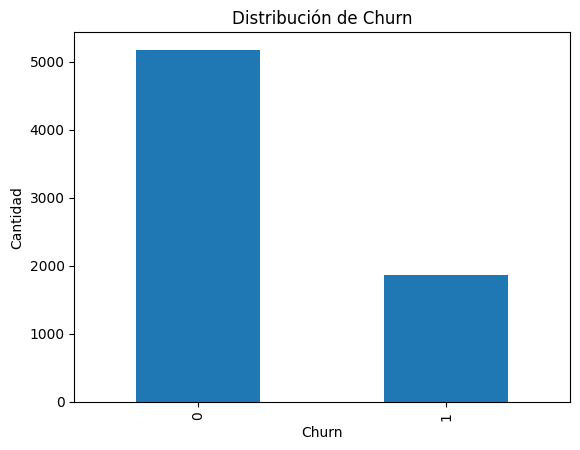

In [17]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.show()


### <font color='purple'>En conlución

*La variable objetivo presenta un desbalance moderado, con 73.4% de clientes activos y 26.53% de clientes que cancelaron. Este desbalance puede afectar el desempeño de los modelos predictivos, por lo que no se debe utilizar únicamente la métrica de accuracy para evaluar el modelo. Se recomienda considerar métricas como recall, precision y F1-score.*

## 5. Normalización o Estandarización

Evalua la necesidad de normalizar o estandarizar los datos, segun los modelos que se aplicaran.
Modelos basados en distancia, como **KNN, SVM, Regresión logistica, y Redes** Neuronales, requieren este prodedimiento. Por otro lado, modelos basados en arboles, como **Decision Tree, Random Forest y XGBoost**, no son sensibles a las escalas de los datos

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
normalizacion = MinMaxScaler()
X_normalizada = normalizacion.fit_transform(X)

In [20]:
pd.DataFrame (X_normalizada)

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.125000,1.0,0.471144,0.066294,0.066294
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.125000,1.0,0.414428,0.060420,0.060420
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.055556,1.0,0.553731,0.030239,0.030239
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.180556,1.0,0.793532,0.140670,0.140670
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.041667,1.0,0.653234,0.028687,0.028687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.180556,1.0,0.367164,0.083556,0.083556
7039,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.305556,1.0,0.665174,0.214043,0.214043
7040,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.027778,1.0,0.318905,0.008533,0.008533
7041,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.930556,1.0,0.493532,0.531831,0.531831


# <font color='blue'>***Correlación y seleción de variables***

## 1. Análisis de correlación

Visualiza la matriz de correlación para identificar relacionews entre varias variables numericas. Presta especial atencion a las variables que muetrean una mayor corelación con la caqncelación, ya que estasn pueden ser fuerte candidatos para el modelos predfictivo

### a) Reconstrucion DataFrame

In [21]:
# Convertir y en DataFrame
y_df = pd.DataFrame(y, columns=['Churn'])

# Asegurarnos que X sea DataFrame
# X es actualmente un array de NumPy. Necesitamos convertirlo a un DataFrame con los nombres de columna correctos.
columnas_originales = one_hot.get_feature_names_out() # Obtener los nombres de las características del transformador one-hot
X = pd.DataFrame(X, columns=columnas_originales) # Convertir X (array de NumPy) a DataFrame con los nombres de columna correctos

# Unir X y y
datos_modelo = pd.concat([X, y_df], axis=1)

datos_modelo.head()

,onehotencoder__genero_Masculino,onehotencoder__multiples_lineas_0,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_Sin servicio de teléfono,onehotencoder__tipo_internet_0,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__seguridad_online_0,onehotencoder__seguridad_online_1,onehotencoder__seguridad_online_Sin servicio de internet,...,onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__mayor_de_60,remainder__posee_pareja,remainder__posee_dependientes,remainder__tiempo_contrato,remainder__servicio_telefono,remainder__valor_mensal,remainder__total_cobrado,remainder__Cuentas_Diarias,Churn
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,9.0,1.0,65.6,593.30,19.776667,0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.0,1.0,59.9,542.40,18.080000,0
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,1.0,73.9,280.85,9.361667,1
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,13.0,1.0,98.0,1237.85,41.261667,1
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,3.0,1.0,83.9,267.40,8.913333,1


### b) Calcular matriz de correlación

In [22]:
correlacion = datos_modelo.corr()

correlacion.head()


,onehotencoder__genero_Masculino,onehotencoder__multiples_lineas_0,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_Sin servicio de teléfono,onehotencoder__tipo_internet_0,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__seguridad_online_0,onehotencoder__seguridad_online_1,onehotencoder__seguridad_online_Sin servicio de internet,...,onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__mayor_de_60,remainder__posee_pareja,remainder__posee_dependientes,remainder__tiempo_contrato,remainder__servicio_telefono,remainder__valor_mensal,remainder__total_cobrado,remainder__Cuentas_Diarias,Churn
onehotencoder__genero_Masculino,1.000000,0.004476,-0.008414,0.006488,0.006026,0.006568,-0.011286,0.010429,-0.017021,0.006026,...,-0.016024,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.014569,0.000048,0.000048,-0.008612
onehotencoder__multiples_lineas_0,0.004476,1.000000,-0.822853,-0.315431,0.310046,-0.070179,-0.190192,-0.118040,-0.151950,0.310046,...,-0.070178,-0.136213,-0.129929,0.023198,-0.323088,0.315431,-0.338314,-0.396765,-0.396765,-0.032569
onehotencoder__multiples_lineas_1,-0.008414,-0.822853,1.000000,-0.279690,-0.210564,-0.199920,0.366083,0.084766,0.098108,-0.210564,...,0.075527,0.142948,0.142057,-0.024526,0.331941,0.279690,0.490434,0.469042,0.469042,0.040102
onehotencoder__multiples_lineas_Sin servicio de teléfono,0.006488,-0.315431,-0.279690,1.000000,-0.172209,0.452425,-0.289999,0.057880,0.092893,-0.172209,...,-0.007556,-0.008576,-0.017706,0.001762,-0.008448,-1.000000,-0.247398,-0.113008,-0.113008,-0.011942
onehotencoder__tipo_internet_0,0.006026,0.310046,-0.210564,-0.172209,1.000000,-0.380635,-0.465793,-0.522429,-0.333403,1.000000,...,-0.002113,-0.182742,0.000615,0.139812,-0.039062,0.172209,-0.763557,-0.374878,-0.374878,-0.227890


### c) Vizualizar matriz completa (Heatmap)

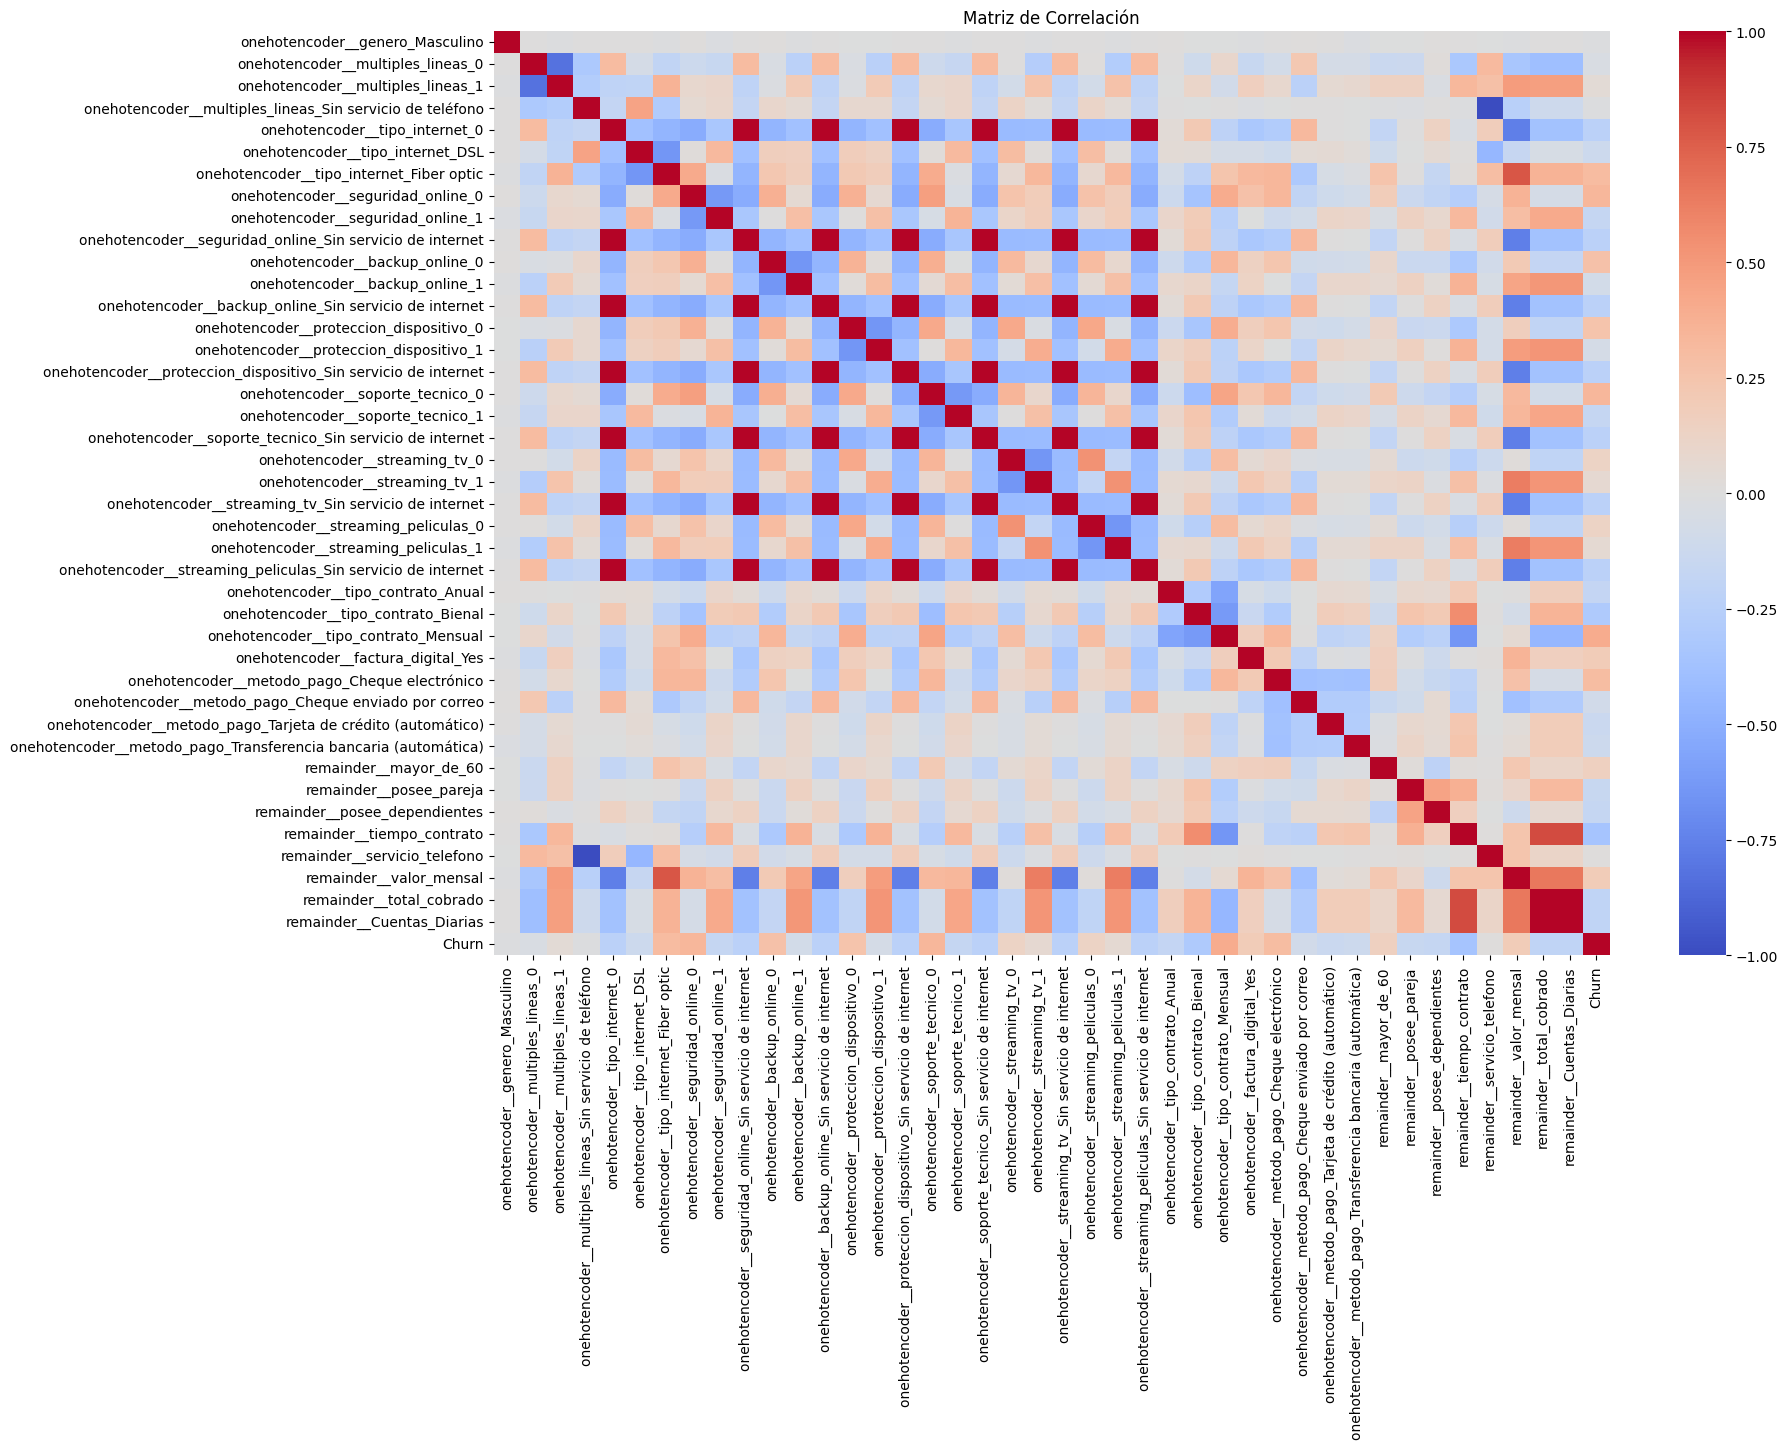

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))
sns.heatmap(correlacion, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación")
plt.show()


* Se observa multicolinealidad estructural esperada por el one-hot encoding (por ejemplo, entre categorías del mismo atributo como tipo de contrato o tipo de internet).

* Hay bloques fuertes de correlación negativa entre:
  
  Categorías “Sin servicio de internet” y variables asociadas a servicios adicionales.

* valor_mensal y total_cobrado muestran correlación positiva considerable.

* tiempo_contrato muestra correlación negativa clara con Churn.

### d) Correlación solo con Churn

In [24]:
correlacion_churn = correlacion['Churn'].sort_values(ascending=False)

correlacion_churn


,Churn
Churn,1.000000
onehotencoder__tipo_contrato_Mensual,0.405103
onehotencoder__seguridad_online_0,0.342637
onehotencoder__soporte_tecnico_0,0.337281
onehotencoder__tipo_internet_Fiber optic,0.308020
onehotencoder__metodo_pago_Cheque electrónico,0.301919
onehotencoder__backup_online_0,0.268005
onehotencoder__proteccion_dispositivo_0,0.252481
remainder__valor_mensal,0.193356
onehotencoder__factura_digital_Yes,0.191825


Variables con mayor correlación positiva con churn:

* tipo_contrato_Mensual

* seguridad_online_0

* soporte_tecnico_0

* tipo_internet_Fiber optic

* metodo_pago_Cheque electrónico

* backup_online_0

* proteccion_dispositivo_0

* valor_mensal

* factura_digital_Yes

🧠 Interpretación:
Clientes con contrato mensual, sin servicios adicionales y con cheque electrónico tienen mayor probabilidad de churn.

### Visualización ordenada

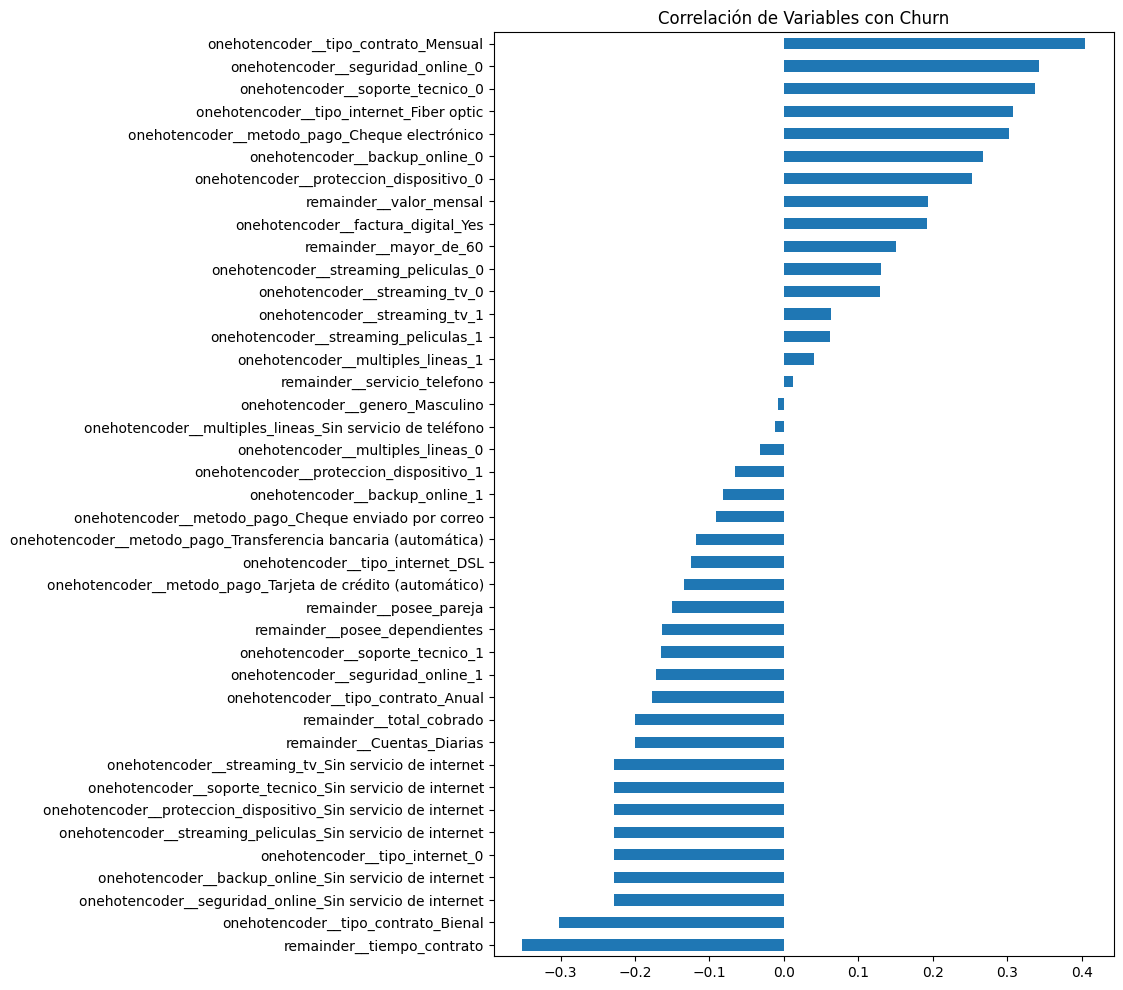

In [25]:
plt.figure(figsize=(8,12))
correlacion_churn.drop('Churn').sort_values().plot(kind='barh')
plt.title("Correlación de Variables con Churn")
plt.show()


Variables con mayor correlación negativa con churn:

* tiempo_contrato (la más fuerte)

* tipo_contrato_Bienal

* “Sin servicio de internet”

* Pago automático (transferencia o tarjeta)

* total_cobrado

* Posee pareja / dependientes

🧠 Interpretación:
Clientes con mayor permanencia y contratos largos presentan menor churn.

## 2. Analis Dirigido

Investiga como variables especificas se relacionan, tales como:

* ***Tiempon de contrato x Cancelacion***
* ***Gato total x Cancelación***

Utiliza graficas como bloxplot o scatter plots para visualizar patrones y posibles tendencias

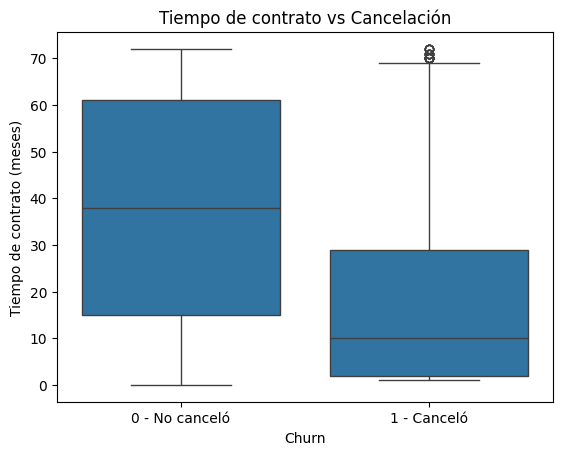

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot Tiempo de contrato vs Churn
plt.figure()
sns.boxplot(x="Churn", y="remainder__tiempo_contrato", data=datos_modelo)
plt.ylabel("Tiempo de contrato (meses)")
plt.xticks([0, 1], ['0 - No canceló', '1 - Canceló'])
plt.title("Tiempo de contrato vs Cancelación")
plt.show()

Lo que se observa:

* Clientes que NO cancelan (Churn = 0):

Mediana ≈ 38 meses

Distribución amplia hasta ~72 meses

* Clientes que SÍ cancelan (Churn = 1):

Mediana ≈ 10 meses

Concentración fuerte en contratos cortos

***Interpretación profesional***

Existe una relación negativa clara entre tiempo de contrato y cancelación.

Clientes con menor antigüedad tienen mayor probabilidad de cancelar.

`tiempo_contrato` es una de las variables más fuertes del modelo (lo confirma tu gráfico de correlación: ≈ -0.35).

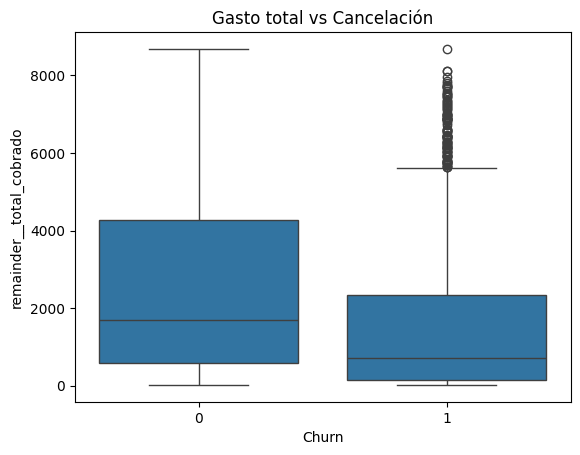

In [45]:
# Boxplot Gasto total vs Churn
plt.figure()
sns.boxplot(x="Churn", y="remainder__total_cobrado", data=datos_modelo)
plt.title("Gasto total vs Cancelación")

plt.show()



Gasto total vs Cancelación (Boxplot)

**Observaciones:**

* Clientes que no cancelan tienen mayor gasto acumulado.

* Clientes que cancelan presentan:

* Mediana menor

* Más outliers altos (clientes que cancelaron después de gastar mucho)

**Interpretación:**

* Esto tiene sentido porque:

* Gasto total está altamente correlacionado con tiempo de contrato.

* Más tiempo → más pagos → mayor total acumulado.

*Pero cuidado:*

gasto_total puede estar introduciendo información redundante si ya tienes tiempo_contrato y valor_mensual.

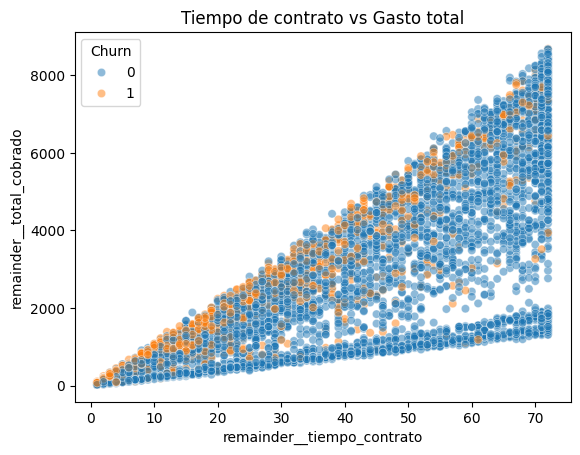

In [34]:
# Scatter plot
plt.figure()
sns.scatterplot(x="remainder__tiempo_contrato",
                y="remainder__total_cobrado",
                hue="Churn",
                data=datos_modelo,
                alpha=0.5)
plt.title("Tiempo de contrato vs Gasto total")
plt.show()

Lo que muestra:

* Relación casi lineal positiva.

* Tres bandas visibles:

    Clientes de bajo plan

    Clientes de plan medio

    Clientes de plan alto

In [49]:
# Promedios por grupo de cancelación

resumen = datos_modelo.groupby('Churn')[[
    'remainder__tiempo_contrato',
    'remainder__total_cobrado'
]].mean()

resumen



,remainder__tiempo_contrato,remainder__total_cobrado
Churn,,
0,37.569965,2555.344141
1,17.979133,1531.796094


# <font color='blue'>***Modelado Predictivo***

## 1. Separación de datos

## 2. Creación de modelos

## 3. Evaluación de los modelos

# <font color='blue'>***Interpretación y Conclusiones***

## 1. Analisis de la importancia de las varibles

## <font color='#FF5733'>***2. Conclusion***